In [4]:
import pandas as pd
d = pd.read_csv('../data/data PM10 mean 2025.csv', sep=";")
d.columns
df = d[["Date de début", "nom site", "Polluant", "valeur", "Latitude", "Longitude"]]

In [10]:
import folium
import branca.colormap as cm

d_clean = d.dropna(subset=["Latitude", "Longitude", "valeur"])

# Colormap
colormap = cm.LinearColormap(
    colors=["green", "yellow", "orange", "red"],
    vmin=d_clean["valeur"].min(),
    vmax=d_clean["valeur"].max(),
    caption="Concentration PM10 (µg/m³)"
)

m = folium.Map(location=[46.5, 2.5], zoom_start=6)
colormap.add_to(m)

for _, row in d_clean.iterrows():
    if row["validité"] == 1:
        couleur = colormap(row["valeur"])
    else:
        couleur = "gray"
    
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=6,
        color=couleur,
        fill=True,
        fill_color=couleur,
        fill_opacity=0.7,
        popup=f"{row['nom site']} : {row['valeur']} µg/m³"
    ).add_to(m)

m.save("carte_pm10.html")
m

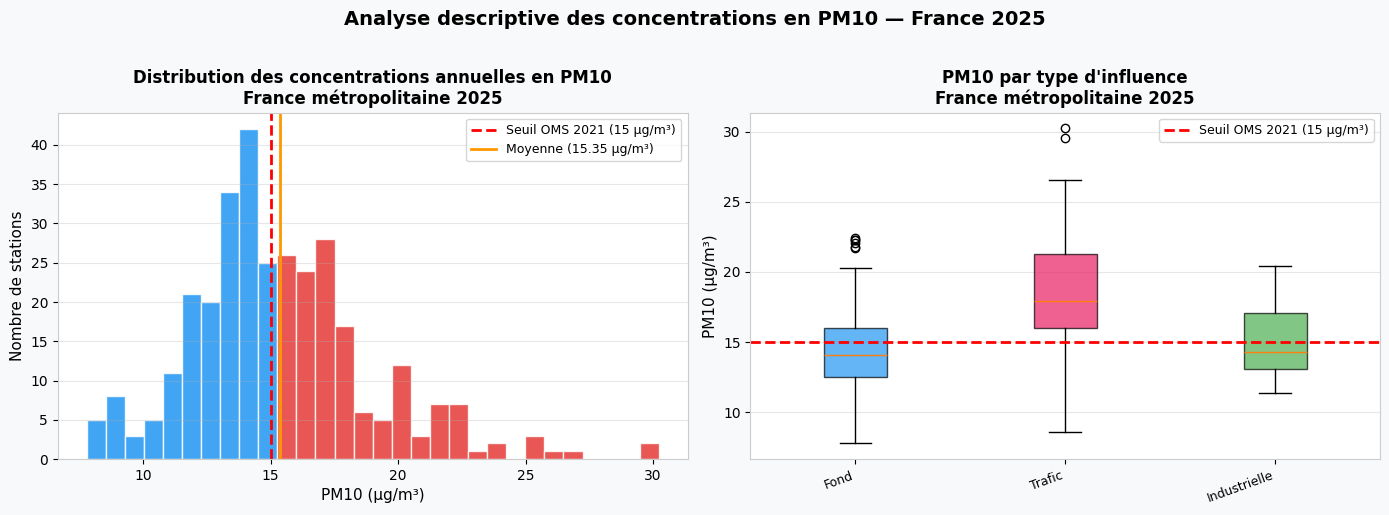

count    319.00
mean      15.35
std        3.60
min        7.77
25%       13.13
50%       14.85
75%       17.07
max       30.23
Name: valeur brute, dtype: float64

Stations au dessus du seuil OMS : 154 / 319 (48.3%)


In [8]:
import matplotlib.pyplot as plt
import numpy as np

d_clean = d_clean[d_clean["validité"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')

# ============================================================
# 1. HISTOGRAMME
# ============================================================

ax = axes[0]
ax.set_facecolor('white')

n, bins, patches = ax.hist(d_clean["valeur brute"], bins=30, 
                            color='#2196F3', edgecolor='white', alpha=0.85)

# Colorier les barres au dessus du seuil OMS en rouge
for patch, left in zip(patches, bins[:-1]):
    if left >= 15:
        patch.set_facecolor('#E53935')

# Ligne seuil OMS
ax.axvline(x=15, color='red', linewidth=2, linestyle='--', label="Seuil OMS 2021 (15 µg/m³)")

# Ligne moyenne
ax.axvline(x=d_clean["valeur brute"].mean(), color='#FF9800', linewidth=2, 
           linestyle='-', label=f"Moyenne ({d_clean['valeur brute'].mean():.2f} µg/m³)")

ax.set_xlabel("PM10 (µg/m³)", fontsize=11)
ax.set_ylabel("Nombre de stations", fontsize=11)
ax.set_title("Distribution des concentrations annuelles en PM10\nFrance métropolitaine 2025", 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

# ============================================================
# 2. BOXPLOT PAR TYPE D'INFLUENCE
# ============================================================

ax2 = axes[1]
ax2.set_facecolor('white')

types = d_clean["type d'influence"].value_counts().index.tolist()
data_box = [d_clean[d_clean["type d'influence"] == t]["valeur brute"].values for t in types]
colors_box = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']

bp = ax2.boxplot(data_box, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors_box[:len(types)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(y=15, color='red', linewidth=2, linestyle='--', label="Seuil OMS 2021 (15 µg/m³)")
ax2.set_xticklabels(types, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel("PM10 (µg/m³)", fontsize=11)
ax2.set_title("PM10 par type d'influence\nFrance métropolitaine 2025", 
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
for spine in ax2.spines.values():
    spine.set_edgecolor('#cccccc')

fig.suptitle("Analyse descriptive des concentrations en PM10 — France 2025",
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Stats descriptives
print(d_clean["valeur brute"].describe().round(2))
print(f"\nStations au dessus du seuil OMS : {(d_clean['valeur brute'] > 15).sum()} / {len(d_clean)} ({(d_clean['valeur brute'] > 15).mean()*100:.1f}%)")

In [9]:
print(d_clean[d_clean["valeur brute"] > 15][['nom site', 'valeur brute', "type d'influence", "type d'implantation"]].sort_values('valeur brute', ascending=False).to_string())

                                  nom site  valeur brute type d'influence     type d'implantation
317                              Reneville     30.230757           Trafic                 Urbaine
30                    Auto A1 -Saint-Denis     29.546033           Trafic                 Urbaine
22                Avignon Rocade De Gaulle     26.562073           Trafic                 Urbaine
303                             ABYMES RN1     26.246758           Trafic             Périurbaine
339                    Montpellier Liberté     25.589753           Trafic                 Urbaine
138                Strasbourg A35 Remparts     25.317513           Trafic                 Urbaine
45                    Bld peripherique Est     25.155034           Trafic                 Urbaine
201                         NICE PROMENADE     24.047866           Trafic                 Urbaine
18                             TOULON FOCH     23.616185           Trafic                 Urbaine
25                  